# 02 — Preprocessing & Unsupervised Clustering

Original MSc project notebook. Normalisation (MinMax / scaling), z-score outlier handling, and the unsupervised pathway: PCA followed by t-SNE and K-Means clustering on age/gender to derive patient age-groups explored as a feature.

In [3]:
# Load the dataset
import pandas as pd

data = pd.read_csv("HDA data.csv")

# Check for missing values
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 ID                          0
Gender                      0
Age                         0
clinico.genetic.subgroup    0
MYCN.status                 0
                           ..
22435.0                     0
17350.0                     0
28875.0                     0
8993.0                      0
32006.0                     0
Length: 38954, dtype: int64


/var/folders/bp/612g8dnd7hv531z_7pdvjlkr0000gn/T/ipykernel_3844/3671747187.py:4: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("HDA data.csv")


In [7]:
# Separate clinical features (non-numeric) and microarray data (numeric)
clinical_data = data.select_dtypes(include=['object'])
numeric_data = data.select_dtypes(include=['float64', 'int64'])



In [9]:
# Check mean and standard deviation for numeric features
feature_means = numeric_data.mean()
feature_std = numeric_data.std()

print("Feature means:\n", feature_means)
print("Feature standard deviations:\n", feature_std)


Feature means:
 Age                 8.358177e+02
Progression         3.941019e-01
DeathFromDisease    2.573727e-01
27262.0             1.523952e-15
3180.0              1.142964e-16
                        ...     
22435.0            -5.714821e-16
17350.0            -1.847792e-15
28875.0            -4.571857e-16
8993.0              1.695397e-15
32006.0             3.390794e-15
Length: 38948, dtype: float64
Feature standard deviations:
 Age                 1103.443693
Progression            0.489313
DeathFromDisease       0.437774
27262.0                1.001343
3180.0                 1.001343
                       ...     
22435.0                1.001343
17350.0                1.001343
28875.0                1.001343
8993.0                 1.001343
32006.0                1.001343
Length: 38948, dtype: float64


In [11]:
# Check if the numeric data is normalized (values between 0 and 1)
is_normalized = (numeric_data >= 0) & (numeric_data <= 1)
normalized_check = is_normalized.all()

print("Are all numeric features normalized (between 0 and 1)?\n", normalized_check)


Are all numeric features normalized (between 0 and 1)?
 Age                 False
Progression          True
DeathFromDisease     True
27262.0             False
3180.0              False
                    ...  
22435.0             False
17350.0             False
28875.0             False
8993.0              False
32006.0             False
Length: 38948, dtype: bool


In [13]:
from sklearn.preprocessing import MinMaxScaler

# Separate the clinical features (first 10 columns) and microarray data (from 11th column onward)
clinical_features = data.iloc[:, :10]
microarray_data = data.iloc[:, 10:]

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Apply the scaler to the microarray data
microarray_data_normalized = pd.DataFrame(scaler.fit_transform(microarray_data), columns=microarray_data.columns)

# Combine the clinical features with the normalized microarray data
data_normalized = pd.concat([clinical_features, microarray_data_normalized], axis=1)


In [15]:
# Save intermediate results to CSV for inspection
data_normalized.to_csv("data_normalized_step.csv", index=False)


In [17]:
from sklearn.preprocessing import MinMaxScaler

# Separate the first 9 columns (clinical features) and include the 10th column in normalization
clinical_features = data.iloc[:, :9]  # First 9 columns
microarray_data = data.iloc[:, 9:]    # From 10th column onward

# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Apply the scaler to the microarray data (starting from the 10th column)
microarray_data_normalized = pd.DataFrame(scaler.fit_transform(microarray_data), columns=microarray_data.columns)

# Combine the clinical features with the normalized microarray data
data_normalized = pd.concat([clinical_features, microarray_data_normalized], axis=1)

# Save and inspect the normalized data
data_normalized.to_csv("data_normalized_step.csv", index=False)
print(data_normalized.head())


         ID Gender     Age clinico.genetic.subgroup MYCN.status INSS.Stage  \
0  ICGC_001      M   987.0                      ST4           1          4   
1  ICGC_002      M  1808.0                      ST4           1          4   
2  ICGC_003      F   625.0                      MNA         Amp          4   
3  ICGC_004      F   335.0                      MNA         Amp         2b   
4  ICGC_005      F   536.0                      MNA         Amp          4   

  HighRisk  Progression  DeathFromDisease   27262.0  ...    3319.0   34832.0  \
0       HR            1                 1  0.643744  ...  0.389336  0.502023   
1       HR            1                 1  0.816456  ...  0.479296  0.659963   
2       HR            1                 1  0.653736  ...  0.547135  0.201185   
3       HR            0                 0  0.590931  ...  0.538876  0.394849   
4       HR            1                 1  0.451049  ...  0.289052  0.357245   

    24669.0   33950.0   39350.0   22435.0   17350.

In [19]:
# Check if the data from the 10th column onward is normalized (between 0 and 1)
is_normalized = (data_normalized.iloc[:, 9:] >= 0) & (data_normalized.iloc[:, 9:] <= 1)
normalized_check = is_normalized.all()

print("Are all features from the 10th column onward normalized (between 0 and 1)?\n", normalized_check)


Are all features from the 10th column onward normalized (between 0 and 1)?
 27262.0     True
3180.0      True
41426.0     True
37033.0     True
6190.0      True
           ...  
22435.0     True
17350.0     True
28875.0     True
8993.0     False
32006.0     True
Length: 38945, dtype: bool


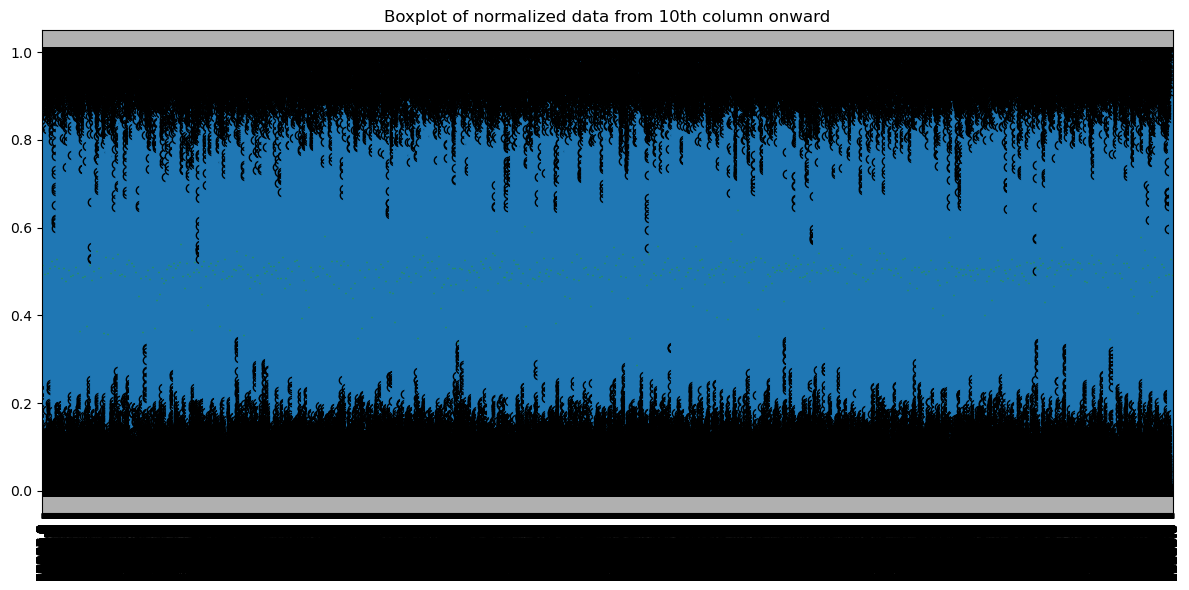

In [22]:
import matplotlib.pyplot as plt

# Generate box plot for all columns starting from the 10th column
plt.figure(figsize=(12, 6))
data_normalized.iloc[:, 9:].boxplot()

plt.title("Boxplot of normalized data from 10th column onward")
plt.xticks(rotation=90)  # Rotate x labels for better readability
plt.tight_layout()

plt.show()


In [24]:
from scipy import stats
import numpy as np

# Calculate Z-scores for the microarray data (starting from the 10th column onward)
z_scores = np.abs(stats.zscore(data_normalized.iloc[:, 9:]))

# Identify outliers (Z-score greater than 3)
outliers = np.where(z_scores > 3)

# Print the outlier positions (row, column) and their Z-scores
outlier_positions = list(zip(outliers[0], outliers[1]))
print(f"Outlier positions (row, column): {outlier_positions}")

# Optionally, inspect the values of the outliers
for row, col in outlier_positions:
    print(f"Outlier value at row {row}, column {col}: {data_normalized.iloc[row, col + 9]} (Z-score: {z_scores[row, col]})")


Outlier positions (row, column): [(0, 101), (0, 2500), (0, 2525), (0, 3800), (0, 5798), (0, 6003), (0, 6368), (0, 6658), (0, 7343), (0, 8502), (0, 8655), (0, 13224), (0, 13254), (0, 14972), (0, 17286), (0, 18669), (0, 19081), (0, 20730), (0, 21131), (0, 22155), (0, 23226), (0, 24226), (0, 25574), (0, 26244), (0, 26336), (0, 28477), (0, 28950), (0, 30799), (0, 31826), (0, 33496), (0, 34593), (0, 35206), (0, 36694), (0, 36743), (0, 37070), (0, 37940), (1, 871), (1, 1362), (1, 1855), (1, 1945), (1, 1958), (1, 2209), (1, 3713), (1, 4572), (1, 5751), (1, 6371), (1, 7649), (1, 7654), (1, 10451), (1, 10557), (1, 12081), (1, 12532), (1, 12783), (1, 14210), (1, 14995), (1, 15224), (1, 15694), (1, 16065), (1, 16190), (1, 17321), (1, 17762), (1, 20128), (1, 20399), (1, 21177), (1, 22010), (1, 23247), (1, 23391), (1, 24386), (1, 25094), (1, 26855), (1, 26896), (1, 27393), (1, 27743), (1, 28099), (1, 30820), (1, 31079), (1, 31347), (1, 31665), (1, 32571), (1, 33376), (1, 33812), (1, 34855), (1, 353

KeyError: (0, 101)

In [26]:
# Convert Gender into numerical values
data_normalized['Gender'] = data_normalized['Gender'].map({'Male': 0, 'Female': 1})


In [28]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Select the relevant features including Age and Gender
pca_features = data_normalized[['Age', 'Gender']].join(data_normalized.iloc[:, 9:])

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_features)

# Plot PCA results
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA including Age and Gender')
plt.show()


ValueError: Input X contains NaN.
PCA does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [30]:
# Check if there are any NaN values in the dataset
nan_check = pca_features.isnull().sum()
print("NaN values in each column:\n", nan_check)


NaN values in each column:
 Age          0
Gender     373
27262.0      0
3180.0       0
41426.0      0
          ... 
22435.0      0
17350.0      0
28875.0      0
8993.0       0
32006.0      0
Length: 38947, dtype: int64


In [32]:
# Replace 'Male' with 0 and 'Female' with 1 in the Gender column
pca_features_cleaned = pca_features.copy()
pca_features_cleaned['Gender'] = pca_features_cleaned['Gender'].map({'Male': 0, 'Female': 1})

# Save the modified dataset for inspection
pca_features_cleaned.to_csv("pca_features_cleaned.csv", index=False)

# Inspect the first few rows to confirm the changes
print(pca_features_cleaned.head())


      Age  Gender   27262.0    3180.0   41426.0   37033.0    6190.0   21664.0  \
0   987.0     NaN  0.643744  0.729023  0.593249  0.639438  0.707516  0.587685   
1  1808.0     NaN  0.816456  0.760928  0.792620  0.626315  0.672021  0.652009   
2   625.0     NaN  0.653736  0.950761  0.406846  0.640631  0.843516  0.464885   
3   335.0     NaN  0.590931  0.382857  0.568936  0.575017  0.462637  0.345009   
4   536.0     NaN  0.451049  0.240881  0.400362  0.619158  0.244081  0.225133   

    10745.0   13510.0  ...    3319.0   34832.0   24669.0   33950.0   39350.0  \
0  0.481527  0.699437  ...  0.389336  0.502023  0.731466  0.317270  0.515610   
1  0.649428  0.654366  ...  0.479296  0.659963  0.605288  0.718215  0.665238   
2  0.676356  0.694429  ...  0.547135  0.201185  0.402307  0.430580  0.508389   
3  0.652596  0.559215  ...  0.538876  0.394849  0.296505  0.536918  0.560383   
4  0.491031  0.474081  ...  0.289052  0.357245  0.434961  0.524715  0.446284   

    22435.0   17350.0   28875.0 

In [34]:
# Replace 'M' with 0 and 'F' with 1 in the Gender column
pca_features_cleaned = pca_features.copy()
pca_features_cleaned['Gender'] = pca_features_cleaned['Gender'].map({'M': 0, 'F': 1})

# Save the modified dataset for inspection
pca_features_cleaned.to_csv("pca_features_cleaned.csv", index=False)

# Inspect the first few rows to confirm the changes
print(pca_features_cleaned.head())


      Age  Gender   27262.0    3180.0   41426.0   37033.0    6190.0   21664.0  \
0   987.0     NaN  0.643744  0.729023  0.593249  0.639438  0.707516  0.587685   
1  1808.0     NaN  0.816456  0.760928  0.792620  0.626315  0.672021  0.652009   
2   625.0     NaN  0.653736  0.950761  0.406846  0.640631  0.843516  0.464885   
3   335.0     NaN  0.590931  0.382857  0.568936  0.575017  0.462637  0.345009   
4   536.0     NaN  0.451049  0.240881  0.400362  0.619158  0.244081  0.225133   

    10745.0   13510.0  ...    3319.0   34832.0   24669.0   33950.0   39350.0  \
0  0.481527  0.699437  ...  0.389336  0.502023  0.731466  0.317270  0.515610   
1  0.649428  0.654366  ...  0.479296  0.659963  0.605288  0.718215  0.665238   
2  0.676356  0.694429  ...  0.547135  0.201185  0.402307  0.430580  0.508389   
3  0.652596  0.559215  ...  0.538876  0.394849  0.296505  0.536918  0.560383   
4  0.491031  0.474081  ...  0.289052  0.357245  0.434961  0.524715  0.446284   

    22435.0   17350.0   28875.0 

In [36]:
# Strip any leading/trailing whitespace and convert to uppercase before mapping
pca_features_cleaned = pca_features.copy()
pca_features_cleaned['Gender'] = pca_features_cleaned['Gender'].str.strip().str.upper().map({'M': 0, 'F': 1})

# Save the modified dataset for inspection
pca_features_cleaned.to_csv("pca_features_cleaned.csv", index=False)

# Inspect the first few rows to confirm the changes
print(pca_features_cleaned.head())


AttributeError: Can only use .str accessor with string values!

In [39]:
# Ensure Gender column is treated as string before applying the mapping
pca_features_cleaned = pca_features.copy()
pca_features_cleaned['Gender'] = pca_features_cleaned['Gender'].astype(str).str.strip().str.upper().map({'M': 0, 'F': 1})

# Save the modified dataset for inspection
pca_features_cleaned.to_csv("pca_features_cleaned.csv", index=False)

# Inspect the first few rows to confirm the changes
print(pca_features_cleaned.head())


      Age  Gender   27262.0    3180.0   41426.0   37033.0    6190.0   21664.0  \
0   987.0     NaN  0.643744  0.729023  0.593249  0.639438  0.707516  0.587685   
1  1808.0     NaN  0.816456  0.760928  0.792620  0.626315  0.672021  0.652009   
2   625.0     NaN  0.653736  0.950761  0.406846  0.640631  0.843516  0.464885   
3   335.0     NaN  0.590931  0.382857  0.568936  0.575017  0.462637  0.345009   
4   536.0     NaN  0.451049  0.240881  0.400362  0.619158  0.244081  0.225133   

    10745.0   13510.0  ...    3319.0   34832.0   24669.0   33950.0   39350.0  \
0  0.481527  0.699437  ...  0.389336  0.502023  0.731466  0.317270  0.515610   
1  0.649428  0.654366  ...  0.479296  0.659963  0.605288  0.718215  0.665238   
2  0.676356  0.694429  ...  0.547135  0.201185  0.402307  0.430580  0.508389   
3  0.652596  0.559215  ...  0.538876  0.394849  0.296505  0.536918  0.560383   
4  0.491031  0.474081  ...  0.289052  0.357245  0.434961  0.524715  0.446284   

    22435.0   17350.0   28875.0 

In [41]:
# Inspect the unique values in the Gender column
print(pca_features['Gender'].unique())


[nan]


In [43]:
# Reload the original dataset
original_data = pd.read_csv("HDA data.csv")  # Replace with the correct path if needed

# Check the unique values in the Gender column from the original dataset
print(original_data['Gender'].unique())


['M' 'F']


/var/folders/bp/612g8dnd7hv531z_7pdvjlkr0000gn/T/ipykernel_3844/545333008.py:2: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  original_data = pd.read_csv("HDA data.csv")  # Replace with the correct path if needed


In [45]:
# Reload the original dataset to get the Gender column
pca_features_cleaned = pca_features.copy()

# Replace the Gender column with the original correct values
pca_features_cleaned['Gender'] = original_data['Gender']

# Map 'M' to 0 and 'F' to 1
pca_features_cleaned['Gender'] = pca_features_cleaned['Gender'].map({'M': 0, 'F': 1})

# Save the modified dataset for inspection
pca_features_cleaned.to_csv("pca_features_cleaned.csv", index=False)

# Inspect the first few rows to confirm the changes
print(pca_features_cleaned.head())


      Age  Gender   27262.0    3180.0   41426.0   37033.0    6190.0   21664.0  \
0   987.0       0  0.643744  0.729023  0.593249  0.639438  0.707516  0.587685   
1  1808.0       0  0.816456  0.760928  0.792620  0.626315  0.672021  0.652009   
2   625.0       1  0.653736  0.950761  0.406846  0.640631  0.843516  0.464885   
3   335.0       1  0.590931  0.382857  0.568936  0.575017  0.462637  0.345009   
4   536.0       1  0.451049  0.240881  0.400362  0.619158  0.244081  0.225133   

    10745.0   13510.0  ...    3319.0   34832.0   24669.0   33950.0   39350.0  \
0  0.481527  0.699437  ...  0.389336  0.502023  0.731466  0.317270  0.515610   
1  0.649428  0.654366  ...  0.479296  0.659963  0.605288  0.718215  0.665238   
2  0.676356  0.694429  ...  0.547135  0.201185  0.402307  0.430580  0.508389   
3  0.652596  0.559215  ...  0.538876  0.394849  0.296505  0.536918  0.560383   
4  0.491031  0.474081  ...  0.289052  0.357245  0.434961  0.524715  0.446284   

    22435.0   17350.0   28875.0 

In [47]:
import pandas as pd

# Reload the original dataset
original_data = pd.read_csv("HDA data.csv")  # Ensure this points to the correct file

# Replace 'M' with 0 and 'F' with 1 in the Gender column
pca_features_cleaned = original_data.copy()
pca_features_cleaned['Gender'] = pca_features_cleaned['Gender'].map({'M': 0, 'F': 1})

# Save the modified dataset and inspect
pca_features_cleaned.to_csv("pca_features_cleaned.csv", index=False)


/var/folders/bp/612g8dnd7hv531z_7pdvjlkr0000gn/T/ipykernel_3844/1754048220.py:4: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  original_data = pd.read_csv("HDA data.csv")  # Ensure this points to the correct file


In [49]:
# Separate clinical features (first 9 columns) and microarray data (starting from the 10th column)
clinical_features = data.iloc[:, :9]
microarray_data = data.iloc[:, 9:]

# Apply Min-Max normalization to microarray data
scaler = MinMaxScaler()
microarray_data_normalized = pd.DataFrame(scaler.fit_transform(microarray_data), columns=microarray_data.columns)

# Combine clinical features with normalized microarray data
data_normalized = pd.concat([clinical_features, microarray_data_normalized], axis=1)


In [51]:
# Save the preprocessed dataset for further analysis
data_normalized.to_csv("data_normalized.csv", index=False)

# Inspect the first few rows to verify
print(data_normalized.head())


         ID Gender     Age clinico.genetic.subgroup MYCN.status INSS.Stage  \
0  ICGC_001      M   987.0                      ST4           1          4   
1  ICGC_002      M  1808.0                      ST4           1          4   
2  ICGC_003      F   625.0                      MNA         Amp          4   
3  ICGC_004      F   335.0                      MNA         Amp         2b   
4  ICGC_005      F   536.0                      MNA         Amp          4   

  HighRisk  Progression  DeathFromDisease   27262.0  ...    3319.0   34832.0  \
0       HR            1                 1  0.643744  ...  0.389336  0.502023   
1       HR            1                 1  0.816456  ...  0.479296  0.659963   
2       HR            1                 1  0.653736  ...  0.547135  0.201185   
3       HR            0                 0  0.590931  ...  0.538876  0.394849   
4       HR            1                 1  0.451049  ...  0.289052  0.357245   

    24669.0   33950.0   39350.0   22435.0   17350.

In [53]:
# Reload the original dataset
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load the dataset
data = pd.read_csv("HDA data.csv")

# Map 'M' with 0 and 'F' with 1 in the Gender column
data['Gender'] = data['Gender'].map({'M': 0, 'F': 1})


/var/folders/bp/612g8dnd7hv531z_7pdvjlkr0000gn/T/ipykernel_3844/1499977892.py:6: DtypeWarning: Columns (4,5) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("HDA data.csv")


In [55]:
# Separate clinical features (first 9 columns) and microarray data (starting from the 10th column)
clinical_features = data.iloc[:, :9]
microarray_data = data.iloc[:, 9:]

# Apply Min-Max normalization to microarray data
scaler = MinMaxScaler()
microarray_data_normalized = pd.DataFrame(scaler.fit_transform(microarray_data), columns=microarray_data.columns)

# Combine clinical features with normalized microarray data
data_normalized = pd.concat([clinical_features, microarray_data_normalized], axis=1)


In [57]:
# Save the preprocessed dataset for further analysis
data_normalized.to_csv("data_normalized.csv", index=False)

# Inspect the first few rows to verify
print(data_normalized.head())


         ID  Gender     Age clinico.genetic.subgroup MYCN.status INSS.Stage  \
0  ICGC_001       0   987.0                      ST4           1          4   
1  ICGC_002       0  1808.0                      ST4           1          4   
2  ICGC_003       1   625.0                      MNA         Amp          4   
3  ICGC_004       1   335.0                      MNA         Amp         2b   
4  ICGC_005       1   536.0                      MNA         Amp          4   

  HighRisk  Progression  DeathFromDisease   27262.0  ...    3319.0   34832.0  \
0       HR            1                 1  0.643744  ...  0.389336  0.502023   
1       HR            1                 1  0.816456  ...  0.479296  0.659963   
2       HR            1                 1  0.653736  ...  0.547135  0.201185   
3       HR            0                 0  0.590931  ...  0.538876  0.394849   
4       HR            1                 1  0.451049  ...  0.289052  0.357245   

    24669.0   33950.0   39350.0   22435.0   

In [59]:
# PCA on Age only
pca_age = PCA(n_components=2)
pca_result_age = pca_age.fit_transform(data_normalized[['Age']])

# Plot PCA results for Age
plt.figure(figsize=(8,6))
plt.scatter(pca_result_age[:, 0], pca_result_age[:, 1], c=data_normalized['Age'], cmap='coolwarm', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA on Age Only')
plt.colorbar(label='Age')
plt.show()


ValueError: n_components=2 must be between 0 and min(n_samples, n_features)=1 with svd_solver='full'

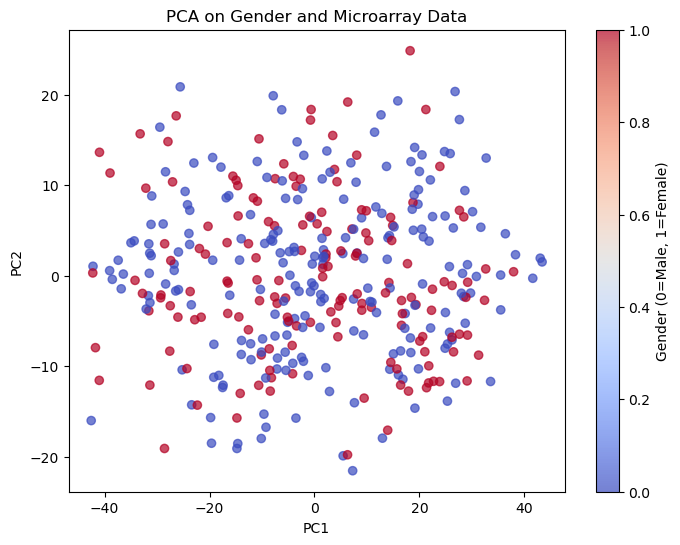

In [61]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Combine Gender and microarray data (assuming microarray data starts at column 10)
pca_features = data_normalized[['Gender']].join(data_normalized.iloc[:, 9:])  # Assuming microarray starts at 10th column

# Perform PCA
pca = PCA(n_components=2)  # Adjust number of components if needed
pca_result = pca.fit_transform(pca_features)

# Plot PCA results
plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=pca_features['Gender'], cmap='coolwarm', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA on Gender and Microarray Data')
plt.colorbar(label='Gender (0=Male, 1=Female)')
plt.show()


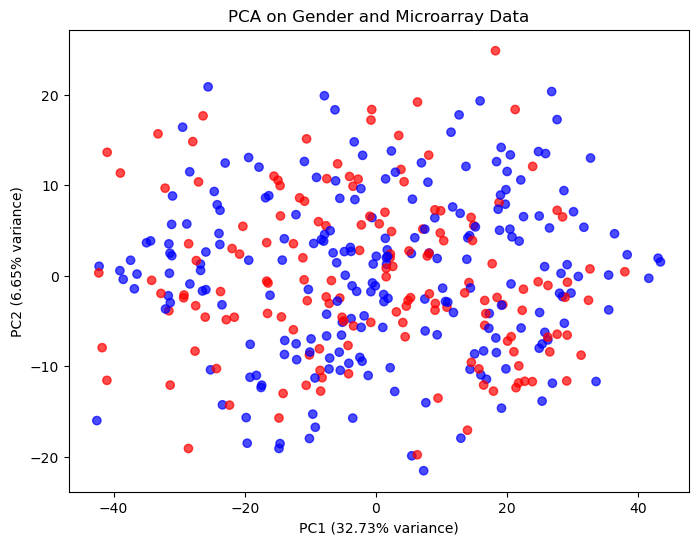

In [63]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Combine Gender and microarray data (assuming microarray data starts at column 10)
pca_features = data_normalized[['Gender']].join(data_normalized.iloc[:, 9:])

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_features)

# Get the explained variance for PC1 and PC2
explained_variance = pca.explained_variance_ratio_

# Plot PCA results without the color bar, using blue for Male and red for Female
colors = ['blue' if gender == 0 else 'red' for gender in pca_features['Gender']]

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=colors, alpha=0.7)
plt.xlabel(f'PC1 ({explained_variance[0] * 100:.2f}% variance)')
plt.ylabel(f'PC2 ({explained_variance[1] * 100:.2f}% variance)')
plt.title('PCA on Gender and Microarray Data')
plt.show()


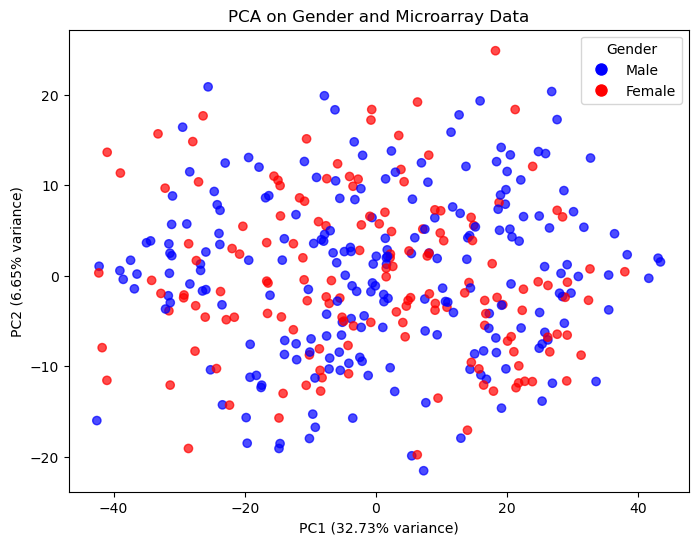

In [65]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Combine Gender and microarray data (assuming microarray data starts at column 10)
pca_features = data_normalized[['Gender']].join(data_normalized.iloc[:, 9:])

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_features)

# Get the explained variance for PC1 and PC2
explained_variance = pca.explained_variance_ratio_

# Plot PCA results without the color bar, using blue for Male and red for Female
colors = ['blue' if gender == 0 else 'red' for gender in pca_features['Gender']]

plt.figure(figsize=(8,6))
plt.scatter(pca_result[:, 0], pca_result[:, 1], c=colors, alpha=0.7, label='Data points')

# Add labels for PC1 and PC2 with variance explained
plt.xlabel(f'PC1 ({explained_variance[0] * 100:.2f}% variance)')
plt.ylabel(f'PC2 ({explained_variance[1] * 100:.2f}% variance)')
plt.title('PCA on Gender and Microarray Data')

# Add legend for colors
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Male'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Female')]
plt.legend(handles=handles, title='Gender')

plt.show()


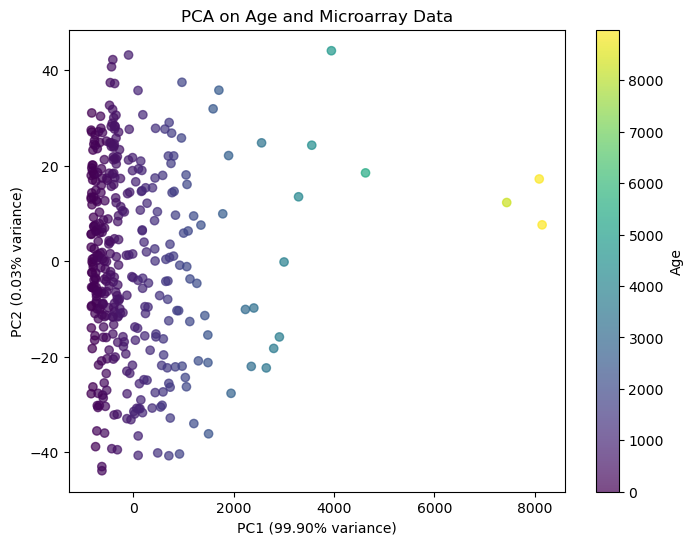

In [67]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Combine Age and microarray data (assuming microarray data starts at column 10)
pca_features = data_normalized[['Age']].join(data_normalized.iloc[:, 9:])

# Perform PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(pca_features)

# Get the explained variance for PC1 and PC2
explained_variance = pca.explained_variance_ratio_

# Plot PCA results with Age as a continuous variable
plt.figure(figsize=(8,6))
sc = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=pca_features['Age'], cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({explained_variance[0] * 100:.2f}% variance)')
plt.ylabel(f'PC2 ({explained_variance[1] * 100:.2f}% variance)')
plt.title('PCA on Age and Microarray Data')

# Add color bar to represent Age
plt.colorbar(sc, label='Age')
plt.show()


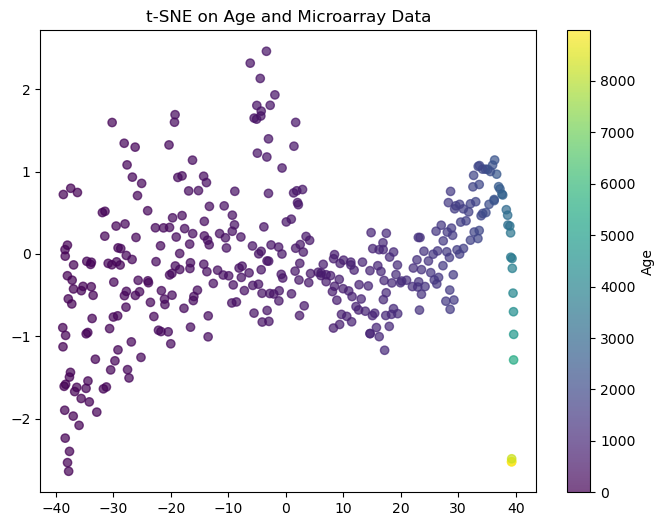

In [71]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Combine Age and microarray data (assuming microarray data starts at column 10)
tsne_features = data_normalized[['Age']].join(data_normalized.iloc[:, 9:])

# Perform t-SNE (set n_components to 2 for 2D visualization)
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(tsne_features)

# Plot t-SNE results with Age as color
plt.figure(figsize=(8,6))
sc = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=tsne_features['Age'], cmap='viridis', alpha=0.7)
plt.title('t-SNE on Age and Microarray Data')
plt.colorbar(sc, label='Age')
plt.show()



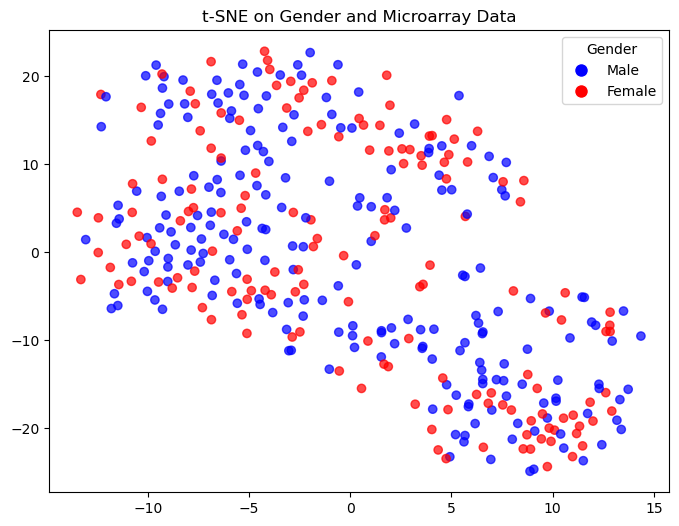

In [73]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Combine Gender and microarray data (assuming microarray data starts at column 10)
tsne_features_gender = data_normalized[['Gender']].join(data_normalized.iloc[:, 9:])

# Perform t-SNE
tsne_gender = TSNE(n_components=2, random_state=42)
tsne_result_gender = tsne_gender.fit_transform(tsne_features_gender)

# Plot t-SNE results with Gender (0=Male, 1=Female)
colors = ['blue' if gender == 0 else 'red' for gender in tsne_features_gender['Gender']]

plt.figure(figsize=(8,6))
plt.scatter(tsne_result_gender[:, 0], tsne_result_gender[:, 1], c=colors, alpha=0.7)
plt.title('t-SNE on Gender and Microarray Data')

# Add legend for Gender
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Male'),
           plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='Female')]
plt.legend(handles=handles, title='Gender')

plt.show()


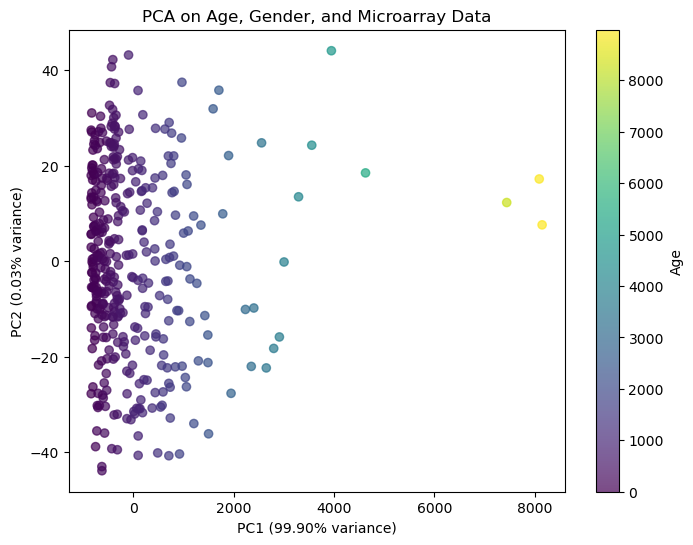

In [75]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Combine Age, Gender, and microarray data
pca_features_combined = data_normalized[['Age', 'Gender']].join(data_normalized.iloc[:, 9:])

# Perform PCA
pca_combined = PCA(n_components=2)
pca_result_combined = pca_combined.fit_transform(pca_features_combined)

# Get the explained variance for PC1 and PC2
explained_variance_combined = pca_combined.explained_variance_ratio_

# Plot PCA results
plt.figure(figsize=(8,6))
plt.scatter(pca_result_combined[:, 0], pca_result_combined[:, 1], c=pca_features_combined['Age'], cmap='viridis', alpha=0.7)
plt.xlabel(f'PC1 ({explained_variance_combined[0] * 100:.2f}% variance)')
plt.ylabel(f'PC2 ({explained_variance_combined[1] * 100:.2f}% variance)')
plt.title('PCA on Age, Gender, and Microarray Data')

# Add color bar to represent Age
plt.colorbar(label='Age')
plt.show()


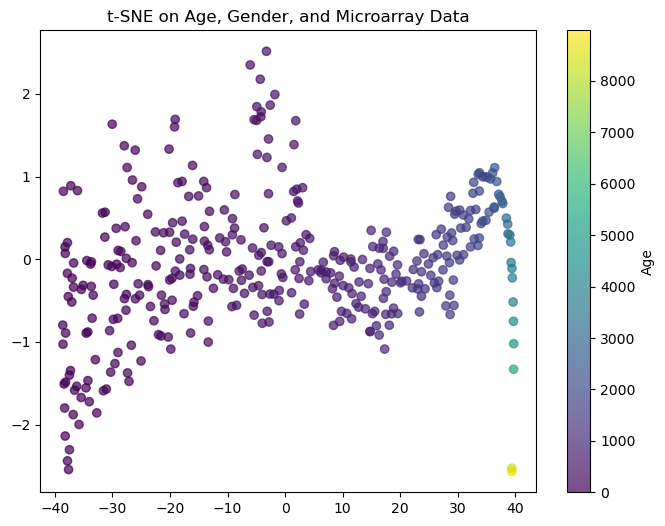

In [77]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Combine Age, Gender, and microarray data
tsne_features_combined = data_normalized[['Age', 'Gender']].join(data_normalized.iloc[:, 9:])

# Perform t-SNE
tsne_combined = TSNE(n_components=2, random_state=42)
tsne_result_combined = tsne_combined.fit_transform(tsne_features_combined)

# Plot t-SNE results with Age as color
plt.figure(figsize=(8,6))
sc = plt.scatter(tsne_result_combined[:, 0], tsne_result_combined[:, 1], c=tsne_features_combined['Age'], cmap='viridis', alpha=0.7)
plt.title('t-SNE on Age, Gender, and Microarray Data')

# Add color bar to represent Age
plt.colorbar(sc, label='Age')
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


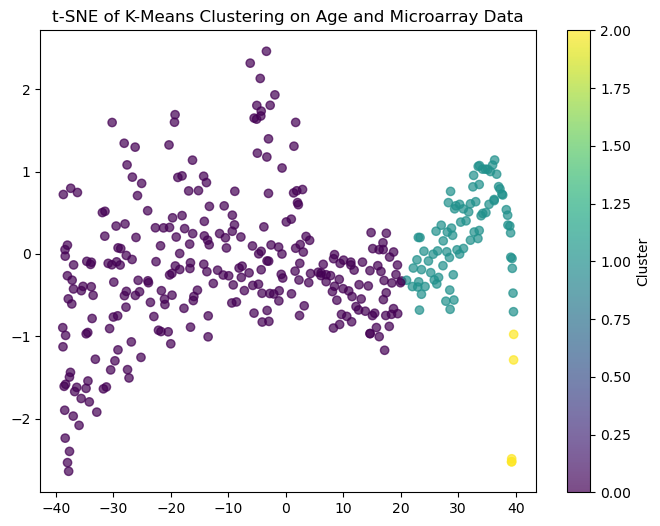

In [79]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Combine Age and microarray data (assuming microarray starts at column 10)
features_for_clustering = data_normalized[['Age']].join(data_normalized.iloc[:, 9:])

# Apply K-Means clustering (e.g., 3 clusters)
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(features_for_clustering)

# Add clusters to the dataframe
features_for_clustering['Cluster'] = clusters

# Plot clusters using t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_result_clusters = tsne.fit_transform(features_for_clustering.iloc[:, :-1])  # Exclude the cluster column for t-SNE

plt.figure(figsize=(8,6))
sc = plt.scatter(tsne_result_clusters[:, 0], tsne_result_clusters[:, 1], c=features_for_clustering['Cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='Cluster')
plt.title('t-SNE of K-Means Clustering on Age and Microarray Data')
plt.show()


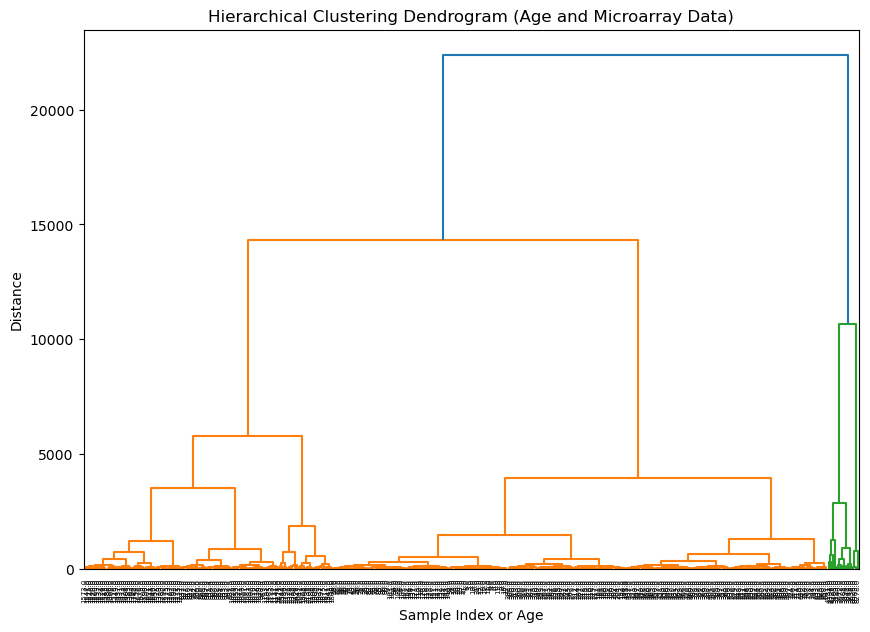

In [81]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
linked = linkage(features_for_clustering.iloc[:, :-1], 'ward')  # Exclude cluster column for hierarchical clustering

# Plot the dendrogram
plt.figure(figsize=(10, 7))
dendrogram(linked, orientation='top', labels=features_for_clustering['Age'].values, distance_sort='descending', show_leaf_counts=True)
plt.title('Hierarchical Clustering Dendrogram (Age and Microarray Data)')
plt.xlabel('Sample Index or Age')
plt.ylabel('Distance')
plt.show()


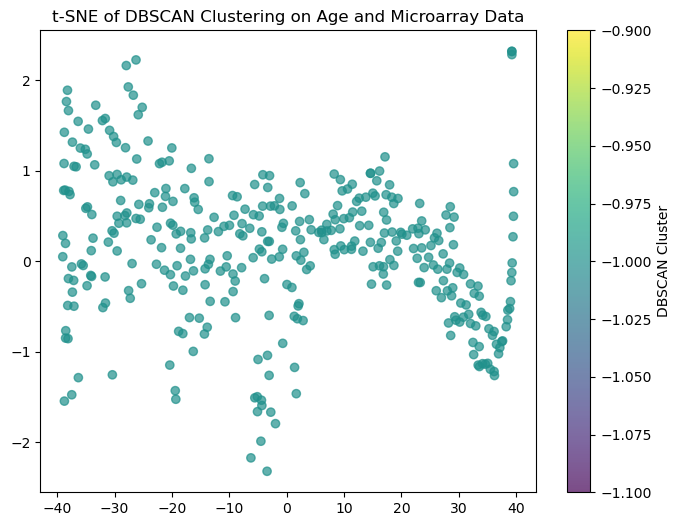

In [83]:
from sklearn.cluster import DBSCAN

# Apply DBSCAN
dbscan = DBSCAN(eps=3, min_samples=5)  # You can adjust eps and min_samples for better results
dbscan_clusters = dbscan.fit_predict(features_for_clustering)

# Plot clusters using t-SNE
features_for_clustering['DBSCAN_Cluster'] = dbscan_clusters
tsne_result_dbscan = tsne.fit_transform(features_for_clustering.iloc[:, :-1])

plt.figure(figsize=(8,6))
sc = plt.scatter(tsne_result_dbscan[:, 0], tsne_result_dbscan[:, 1], c=features_for_clustering['DBSCAN_Cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='DBSCAN Cluster')
plt.title('t-SNE of DBSCAN Clustering on Age and Microarray Data')
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/sklearn/

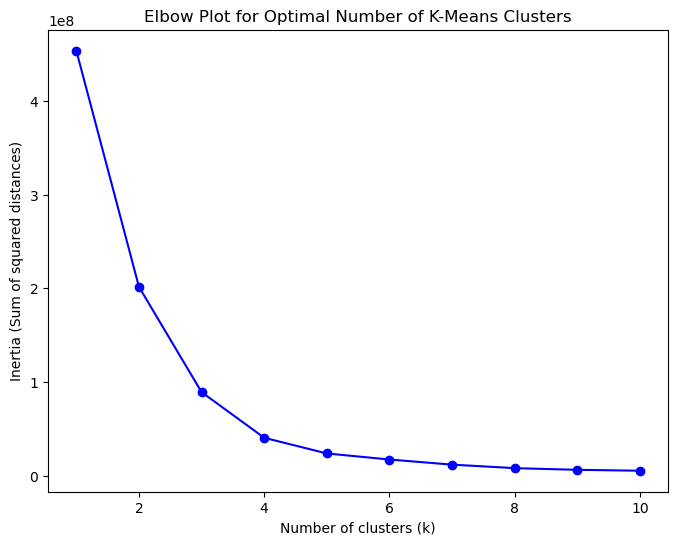

In [85]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Combine Age and microarray data (assuming microarray starts at column 10)
features_for_clustering = data_normalized[['Age']].join(data_normalized.iloc[:, 9:])

# Calculate inertia for a range of cluster numbers
inertia = []
cluster_range = range(1, 11)  # Try from 1 to 10 clusters
for k in cluster_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_for_clustering)
    inertia.append(kmeans.inertia_)

# Plot the elbow plot
plt.figure(figsize=(8,6))
plt.plot(cluster_range, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia (Sum of squared distances)')
plt.title('Elbow Plot for Optimal Number of K-Means Clusters')
plt.show()


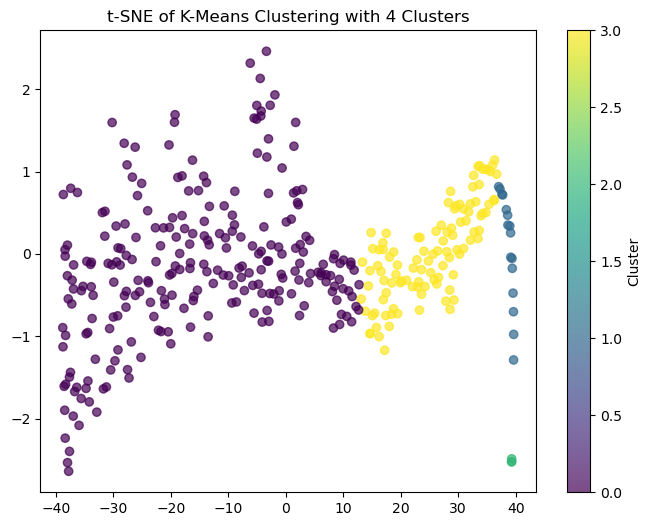

In [87]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Combine Age and microarray data (assuming microarray starts at column 10)
features_for_clustering = data_normalized[['Age']].join(data_normalized.iloc[:, 9:])

# Apply K-Means clustering with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(features_for_clustering)

# Add the clusters to the dataframe
features_for_clustering['Cluster'] = clusters

# Perform t-SNE for visualization
tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(features_for_clustering.iloc[:, :-1])  # Exclude the 'Cluster' column for t-SNE

# Plot the t-SNE results, color-coded by the cluster
plt.figure(figsize=(8,6))
sc = plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=features_for_clustering['Cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='Cluster')
plt.title('t-SNE of K-Means Clustering with 4 Clusters')
plt.show()


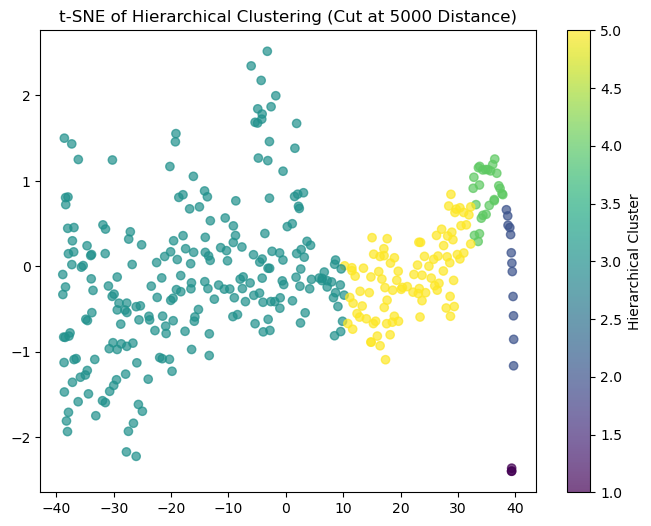

In [91]:
from scipy.cluster.hierarchy import fcluster

# Perform hierarchical clustering (you already have this step done)
# linked = linkage(features_for_clustering.iloc[:, :-1], 'ward')

# Cut the dendrogram at a distance of 5000 to form clusters
clusters_hierarchical = fcluster(linked, t=5000, criterion='distance')

# Add hierarchical clusters to the dataframe
features_for_clustering['Hierarchical_Cluster'] = clusters_hierarchical

# Perform t-SNE for visualization of the hierarchical clusters
tsne_result_hierarchical = tsne.fit_transform(features_for_clustering.iloc[:, :-1])

# Plot t-SNE results, colored by hierarchical clusters
plt.figure(figsize=(8,6))
sc = plt.scatter(tsne_result_hierarchical[:, 0], tsne_result_hierarchical[:, 1], c=features_for_clustering['Hierarchical_Cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(sc, label='Hierarchical Cluster')
plt.title('t-SNE of Hierarchical Clustering (Cut at 5000 Distance)')
plt.show()
